## TIME SERIES FORECASTING

In [ ]:
#Tahminlerin gerçek fiyatlardan ortalama sapma miktarını ölçmek için kullanılmıştır.

#Trend Doğruluğu: Modelin uzun vadeli fiyat yönünü (yükseliş/düşüş) ne kadar tutarlı yakaladığı görselleştirme ile test edildi

#En İyi Çözümün Anahtarı
#Date-to-Ordinal Transformation: Makine öğrenmesi modellerinin tarih verilerini işleyebilmesi için tarihler sayısal (ordinal) formata dönüştürülmüştür.

#Non-Shuffled Splitting:  (shuffle=False) bölünmüştür. Bu, modelin geçmişten öğrenip geleceği tahmin etmesini sağlar.

#Notlar ve Öğrenilenler
#Zamanın Etkisi: Hisse senedi fiyatlarının sadece bağımsız değişkenlere değil, zamanın kendisine bağlı bir eğilimi (trend) olduğu gözlemlenmiştir.
#Lineer Yaklaşım: Çok oynak (volatil) verilerde bile basit bir Lineer Regresyon modelinin, ana resmi ve genel gidişatı göstermedeki başarısı tecrübe edilmiştir.

#Gelecek Sızıntısı (Data Leakage): Zaman serilerinde test verisinin eğitim verisinden daha ileri bir tarihte olması gerektiği, aksi takdirde modelin "geleceği ezberleyeceği" riski öğrenilmiştir.

In [1]:
##Netflix Stock Price Prediction

✅ Dosya 'NFLX.csv.csv' olarak bulundu ve yüklendi.


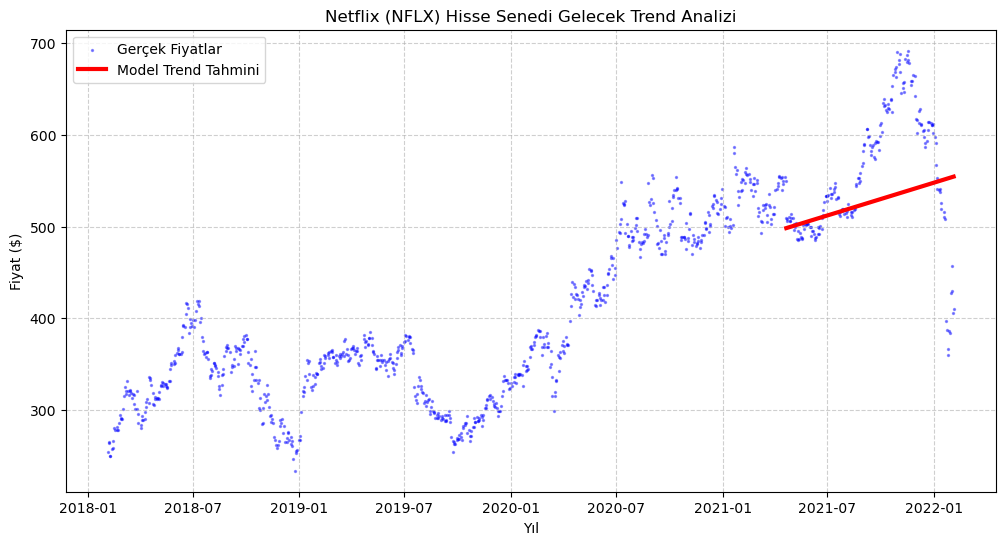


🚀 BAŞARI: Model 'netflix_trend_model.pkl' adıyla kaydedildi.
📊 Ortalama Hata (MAE): 54.03 USD


In [5]:
# ==========================================
# 5. PROJE: NETFLIX TREND ANALİZİ (GÜVENLİ YÜKLEME)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import datetime as dt
import joblib
import os

# --- 1. AKILLI DOSYA YÜKLEME ---
filename = 'NFLX.csv'

if os.path.exists(filename):
    df = pd.read_csv(filename)
    print(f"✅ Dosya bulundu ve yüklendi: {filename}")
elif os.path.exists('NFLX.csv.csv'):
    df = pd.read_csv('NFLX.csv.csv')
    print("✅ Dosya 'NFLX.csv.csv' olarak bulundu ve yüklendi.")
else:
    # Eğer hala bulunamazsa klasördeki dosyaları göster ki hatayı anlayalım
    print("❌ HATA: Dosya bulunamadı!")
    print("📍 Şu anki klasördeki dosyalar:", os.listdir())
    # Durdurmamak için örnek bir hata mesajı basalım
    raise FileNotFoundError("Lütfen NFLX.csv dosyasının notebook ile aynı klasörde olduğundan emin ol.")

# --- 2. VERİ ÖN İŞLEME ---
# Tarih formatına çevir
df['Date'] = pd.to_datetime(df['Date'])
# Regresyon için tarihi sayısal (Ordinal) formata çevir
df['Date_Ordinal'] = df['Date'].map(dt.datetime.toordinal)

# --- 3. ÖZELLİK VE HEDEF BELİRLEME ---
X = df[['Date_Ordinal']] # Zaman
y = df['Close']          # Fiyat

# --- 4. ZAMAN SERİSİ BÖLME (Shuffle=False Önemli!) ---
# Verinin sırasını bozmadan son %20'yi test için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- 5. MODEL EĞİTİMİ ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- 6. TAHMİN VE GÖRSELLEŞTİRME ---
y_pred = model.predict(X_test)

plt.figure(figsize=(12,6))
plt.scatter(df['Date'], y, color='blue', s=2, label='Gerçek Fiyatlar', alpha=0.4)
plt.plot(df['Date'].iloc[len(X_train):], y_pred, color='red', label='Model Trend Tahmini', linewidth=3)
plt.title('Netflix (NFLX) Hisse Senedi Gelecek Trend Analizi')
plt.xlabel('Yıl')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 7. KAYDETME ---
joblib.dump(model, 'netflix_trend_model.pkl')
print(f"\n🚀 BAŞARI: Model 'netflix_trend_model.pkl' adıyla kaydedildi.")
print(f"📊 Ortalama Hata (MAE): {mean_absolute_error(y_test, y_pred):.2f} USD")